# Unrolled QPA Transpilation Scaling — Overview (T=1, 2, 3)

Combined view of how the **2Q depth** and **2Q gate count** of the unrolled QPA circuit (longest-path, static) scale with `N` across `T = 1, 2, 3`.

Data is loaded from the per-T result files written by the individual scaling notebooks:
- `scaling_results/T1/scaling_results_T1.json`
- `scaling_results/T2/scaling_results_T2.json`
- `scaling_results/T3/scaling_results_T3.json`

Plots show **best of N seeds only** (no averages). Backends compared: `ibm_boston`, `ibm_miami`.

In [7]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

RESULTS_ROOT = Path("scaling_results")
T_LIST = [1, 2, 3]
BACKENDS = ["ibm_boston", "ibm_miami"]

## Load results
Concatenate the per-T JSONs into a single DataFrame, dropping any errored rows.

In [8]:
frames = []
for t in T_LIST:
    path = RESULTS_ROOT / f"T{t}" / f"scaling_results_T{t}.json"
    if not path.exists():
        print(f"[skip] {path} not found")
        continue
    with open(path) as f:
        rows = json.load(f)
    df_t = pd.DataFrame(rows)
    df_t["t"] = t
    frames.append(df_t)

df = pd.concat(frames, ignore_index=True)
df = df[df["best_2q_depth"].notna()].copy()
df = df.sort_values(["t", "backend", "n"]).reset_index(drop=True)
print(f"Loaded {len(df)} rows across T = {sorted(df['t'].unique())}")

Loaded 66 rows across T = [np.int64(1), np.int64(2), np.int64(3)]


## Summary table
One row per `(T, backend, N)` with the best-seed 2Q depth and 2Q gate count.

In [9]:
table = df[["t", "backend", "n", "best_seed", "best_2q_depth", "best_2q_gates"]].rename(
    columns={
        "t": "T",
        "n": "N",
        "best_seed": "Best Seed",
        "best_2q_depth": "Best 2Q Depth",
        "best_2q_gates": "Best 2Q Gates",
    }
)
table

,T,backend,N,Best Seed,Best 2Q Depth,Best 2Q Gates
0,1,ibm_boston,3,0,18,20
1,1,ibm_boston,5,0,18,40
2,1,ibm_boston,7,0,18,60
3,1,ibm_boston,9,0,18,80
4,1,ibm_boston,11,17,18,100
...,...,...,...,...,...,...
61,3,ibm_miami,15,6,70,566
62,3,ibm_miami,17,91,71,636
63,3,ibm_miami,19,29,77,753
64,3,ibm_miami,21,37,79,864


### Pivot: Best 2Q depth vs N (rows = N, cols = (backend, T))

In [10]:
pivot_depth = df.pivot_table(
    index="n", columns=["backend", "t"], values="best_2q_depth"
).sort_index()
pivot_depth

backend ibm_boston              ibm_miami            
t                1     2      3         1     2     3
n                                                    
3             18.0  34.0   46.0      16.0  28.0  38.0
5             18.0  37.0   50.0      18.0  31.0  48.0
7             18.0  37.0   73.0      18.0  32.0  58.0
9             18.0  44.0   86.0      18.0  37.0  60.0
11            18.0  47.0   84.0      18.0  37.0  64.0
13            22.0  52.0   85.0      18.0  39.0  67.0
15            18.0  54.0   99.0      18.0  42.0  70.0
17            18.0  52.0  102.0      18.0  44.0  71.0
19            22.0  65.0  107.0      18.0  46.0  77.0
21            22.0  59.0   97.0      19.0  50.0  79.0
23            22.0  62.0  101.0      19.0  54.0  81.0

### Pivot: Best 2Q gate count vs N (rows = N, cols = (backend, T))

In [11]:
pivot_gates = df.pivot_table(
    index="n", columns=["backend", "t"], values="best_2q_gates"
).sort_index()
pivot_gates

backend ibm_boston                ibm_miami              
t                1      2       3         1      2      3
n                                                        
3             20.0   49.0    78.0      18.0   40.0   63.0
5             40.0  106.0   164.0      40.0   90.0  140.0
7             60.0  155.0   297.0      60.0  135.0  232.0
9             80.0  227.0   399.0      80.0  189.0  311.0
11           100.0  277.0   495.0      98.0  246.0  393.0
13           123.0  360.0   649.0     120.0  283.0  480.0
15           140.0  410.0   713.0     140.0  347.0  566.0
17           160.0  483.0   861.0     160.0  398.0  636.0
19           188.0  603.0   961.0     180.0  475.0  753.0
21           212.0  620.0  1132.0     203.0  507.0  864.0
23           235.0  657.0  1191.0     221.0  584.0  949.0

## Scaling plots (best of seeds only)

Color = backend, linestyle = `T`.

Saved plot to scaling_results/scaling_overview_best.png


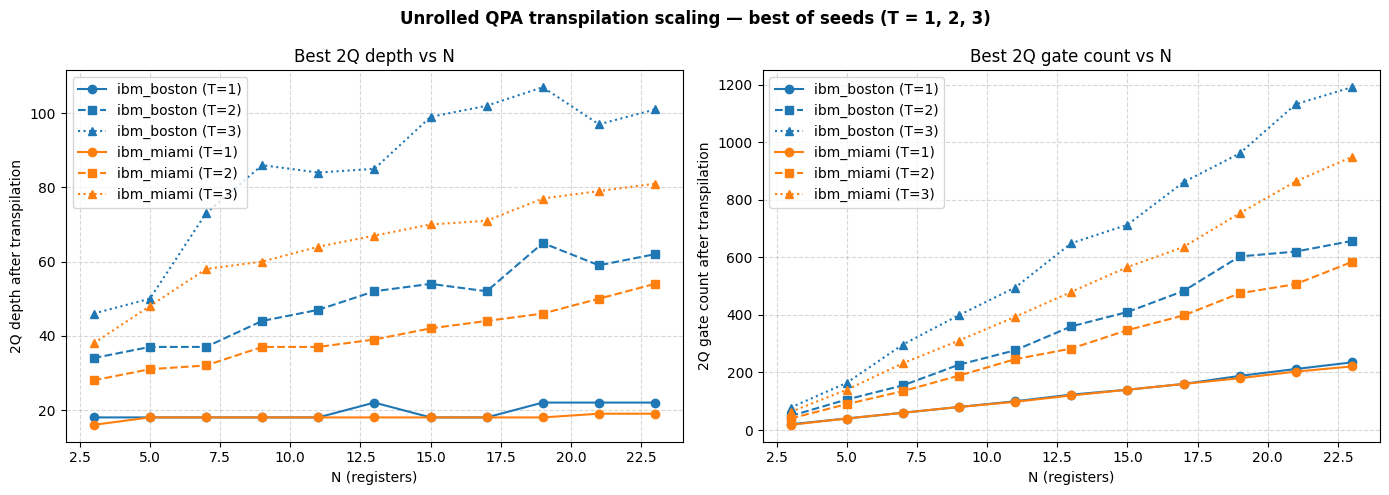

In [12]:
colors = {"ibm_boston": "#1f77b4", "ibm_miami": "#ff7f0e"}
linestyles = {1: "-", 2: "--", 3: ":"}
markers = {1: "o", 2: "s", 3: "^"}

fig, (ax_d, ax_g) = plt.subplots(1, 2, figsize=(14, 5))

for backend_name in BACKENDS:
    for t in T_LIST:
        sub = df[(df["backend"] == backend_name) & (df["t"] == t)].sort_values("n")
        if sub.empty:
            continue
        c = colors.get(backend_name)
        ls = linestyles.get(t, "-")
        mk = markers.get(t, "o")
        label = f"{backend_name} (T={t})"
        ax_d.plot(sub["n"], sub["best_2q_depth"], marker=mk, linestyle=ls, color=c, label=label)
        ax_g.plot(sub["n"], sub["best_2q_gates"], marker=mk, linestyle=ls, color=c, label=label)

ax_d.set_xlabel("N (registers)")
ax_d.set_ylabel("2Q depth after transpilation")
ax_d.set_title("Best 2Q depth vs N")
ax_d.grid(True, linestyle="--", alpha=0.5)
ax_d.legend()

ax_g.set_xlabel("N (registers)")
ax_g.set_ylabel("2Q gate count after transpilation")
ax_g.set_title("Best 2Q gate count vs N")
ax_g.grid(True, linestyle="--", alpha=0.5)
ax_g.legend()

fig.suptitle("Unrolled QPA transpilation scaling — best of seeds (T = 1, 2, 3)", fontweight="bold")
plt.tight_layout()

overview_path = RESULTS_ROOT / "scaling_overview_best.png"
plt.savefig(overview_path, dpi=200, bbox_inches="tight")
print(f"Saved plot to {overview_path}")
plt.show()

## Per-T scaling plots

One plot per `T` value, showing best 2Q depth and gate count vs N for each backend.

Saved plot to scaling_results/T1/scaling_plot_T1_best.png


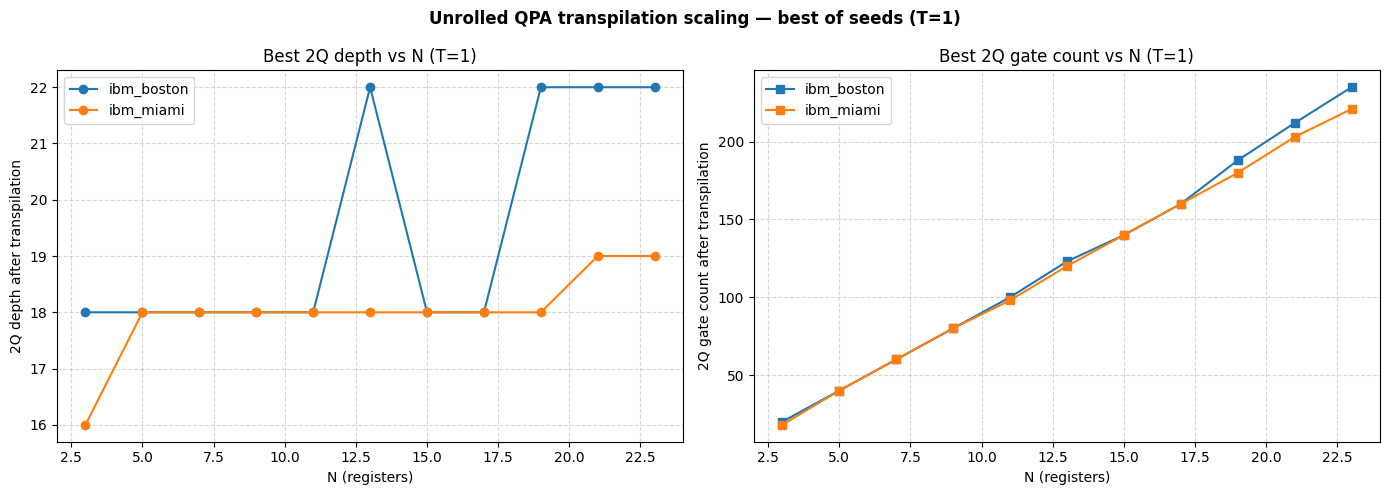

Saved plot to scaling_results/T2/scaling_plot_T2_best.png


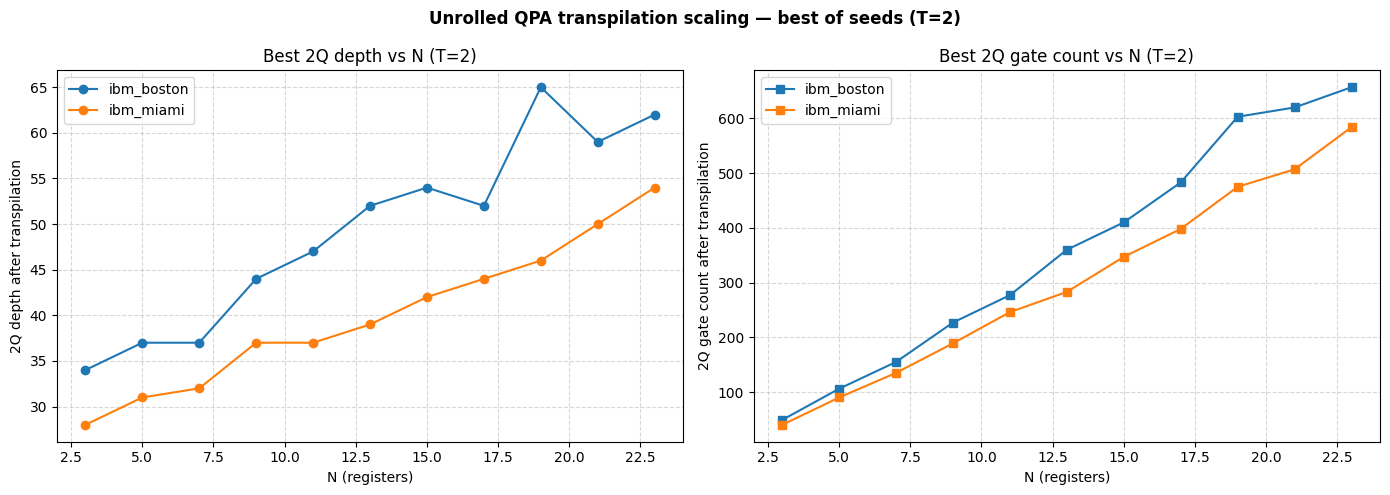

Saved plot to scaling_results/T3/scaling_plot_T3_best.png


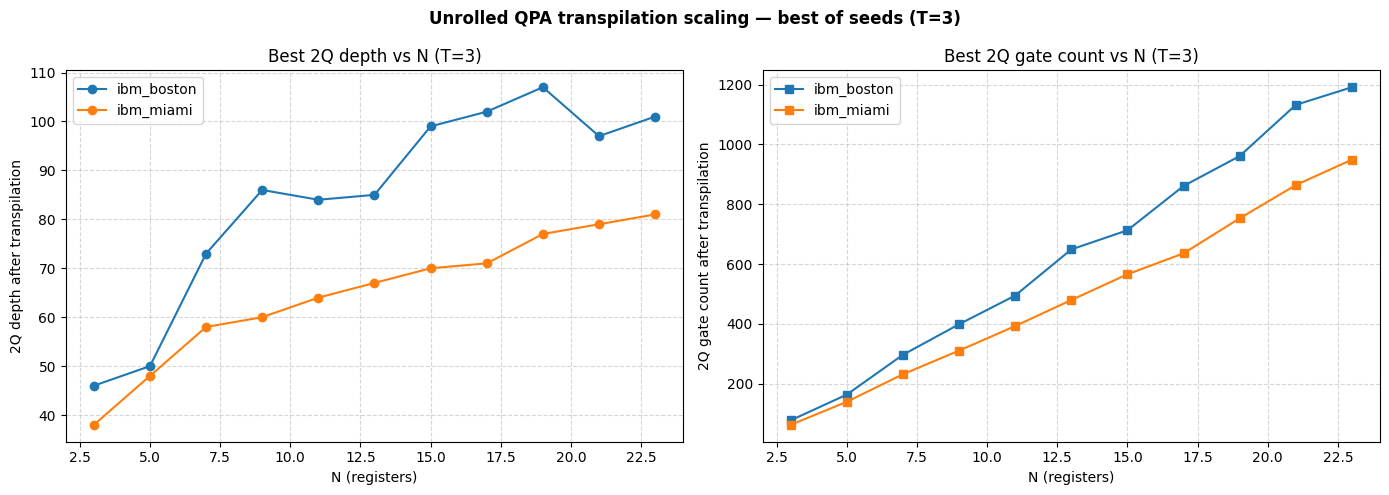

In [13]:
for t in T_LIST:
    sub_t = df[df["t"] == t]
    if sub_t.empty:
        print(f"[skip] no data for T={t}")
        continue

    fig, (ax_d, ax_g) = plt.subplots(1, 2, figsize=(14, 5))

    for backend_name in BACKENDS:
        sub = sub_t[sub_t["backend"] == backend_name].sort_values("n")
        if sub.empty:
            continue
        c = colors.get(backend_name)
        ax_d.plot(sub["n"], sub["best_2q_depth"], marker="o", color=c, label=backend_name)
        ax_g.plot(sub["n"], sub["best_2q_gates"], marker="s", color=c, label=backend_name)

    ax_d.set_xlabel("N (registers)")
    ax_d.set_ylabel("2Q depth after transpilation")
    ax_d.set_title(f"Best 2Q depth vs N (T={t})")
    ax_d.grid(True, linestyle="--", alpha=0.5)
    ax_d.legend()

    ax_g.set_xlabel("N (registers)")
    ax_g.set_ylabel("2Q gate count after transpilation")
    ax_g.set_title(f"Best 2Q gate count vs N (T={t})")
    ax_g.grid(True, linestyle="--", alpha=0.5)
    ax_g.legend()

    fig.suptitle(f"Unrolled QPA transpilation scaling — best of seeds (T={t})", fontweight="bold")
    plt.tight_layout()

    per_t_path = RESULTS_ROOT / f"T{t}" / f"scaling_plot_T{t}_best.png"
    plt.savefig(per_t_path, dpi=200, bbox_inches="tight")
    print(f"Saved plot to {per_t_path}")
    plt.show()